In [1]:
# --- CÉLULA 1: Imports e Configuração ---
import sys
import os
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_score,
                             roc_auc_score, roc_curve, recall_score, f1_score,
                             precision_recall_curve, average_precision_score)

# Endpoint/credenciais do MinIO: variáveis de ambiente têm precedência (dentro
# do Docker o compose já as define). Fora do Docker, caem nos padrões do stack
# local de desenvolvimento (ver README).
os.environ.setdefault("MINIO_ENDPOINT", "http://localhost:9000")
os.environ.setdefault("AWS_ACCESS_KEY_ID", "minioadmin")
os.environ.setdefault("AWS_SECRET_ACCESS_KEY", "minioadmin123")

# Localização da raiz e config
PROJECT_ROOT = Path.cwd().parent
with open(PROJECT_ROOT / "Model" / "config.yml", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

sys.path.insert(0, str(PROJECT_ROOT))
from storage import get_storage

store = get_storage(cfg)

# Carrega os dados de teste do bucket "models" (não do filesystem local)
with store.open("models", "evaluation_data/X_test.pkl", "rb") as fh:
    X_test = joblib.load(fh)
with store.open("models", "evaluation_data/y_test.pkl", "rb") as fh:
    y_test = joblib.load(fh)
with store.open("models", "evaluation_data/feature_names.pkl", "rb") as fh:
    feature_names = joblib.load(fh)

resultados = []

In [2]:
# --- CÉLULA 2: Funções auxiliares ---

def carregar_modelo(store, model_name):
    model_key = f"models/{model_name}/model.pkl"
    threshold_key = f"models/{model_name}/threshold.txt"

    print(f"Carregando: {model_key}")

    with store.open("models", model_key, "rb") as fh:
        model = joblib.load(fh)

    with store.open("models", threshold_key, "r") as fh:
        threshold = float(fh.read())

    return model, threshold


def alinhar_features(model, X_test):
    if hasattr(model, "feature_names_in_"):
        features_esperadas = model.feature_names_in_

    elif hasattr(model, "named_steps") and "model" in model.named_steps:
        features_esperadas = model.named_steps["model"].feature_names_in_

    else:
        features_esperadas = X_test.columns

    X_aligned = X_test.reindex(columns=features_esperadas, fill_value=0)

    return X_aligned

In [3]:
# --- CÉLULA 3: Avaliação Dinâmica de Modelos (Corrigida) ---

print("--- Iniciando comparativo com Thresholds Otimizados ---")

model_names = [name for name, info in cfg["models"].items() if info.get("enabled", True)]

for model_name in model_names:
    model, threshold = carregar_modelo(store, model_name)
    X_aligned = alinhar_features(model, X_test)

    # 3. Predição e Métricas
    probs = model.predict_proba(X_aligned)[:, 1]
    y_pred = (probs >= threshold).astype(int)

    auc = roc_auc_score(y_test, probs)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    resultados.append({
       'Modelo': model_name,
       'ROC AUC': auc,
       'Acurácia': acc,
       'Precisão': prec,
       'Recall': recall,
       'F1': f1,
       'Threshold': threshold
    })

# --- PROTEÇÃO CONTRA O KEYERROR ---
if resultados:
    df_resumo = pd.DataFrame(resultados)
    df_resumo = df_resumo.sort_values(by='ROC AUC', ascending=False)
    display(df_resumo)
else:
    print("ERRO: Nenhuma métrica foi coletada. Verifique se o bucket 'models' no MinIO tem model.pkl e threshold.txt para cada modelo em cfg['models'].")

--- Iniciando comparativo com Thresholds Otimizados ---
Carregando: models/XGBOOST/model.pkl


Carregando: models/RANDOM_FOREST/model.pkl


Carregando: models/LOGISTIC_REGRESSION/model.pkl


,Modelo,ROC AUC,Acurácia,Precisão,Recall,F1,Threshold
0,XGBOOST,0.771782,0.614279,0.147909,0.793555,0.249343,0.349770
2,LOGISTIC_REGRESSION,0.758208,0.494578,0.123870,0.866264,0.216746,0.349997
1,RANDOM_FOREST,0.745601,0.746549,0.179818,0.600806,0.276793,0.100000


## XGBoost e o ROC-AUC

O XGBoost foi o modelo com o maior ROC-AUC. 

O ROC-AUC métrica é a mais importante neste problema porque mede a capacidade do modelo separar clientes inadimplentes dos adimplentes independentemente do threshold escolhido.
Recall de 79,4%   (TP / TP + FN)
Precision de 14,8% (TP / TP + FP)

Este modelo identifica aproximadamente 79% dos clientes inadimplentes (recall), embora produza muitos falsos positivos.

Com isso em mente, os modelos foram treinados com o ROC-AUC como a principal métrica a maximizar. Usamos uma métrica secundária no treino (Recall >= 0.7) para dar mais peso à classificações corretas dos inadimplentes, pois no contexto de negócio, são os que mais causam prejuízo. 

## Interpretação destas métricas

- ROC-AUC: O quão bem o modelo separa clientes de alto e baixo risco em geral?
- Acurácia: Quantas previsões totais estão corretas.
- Precisão: Dos clientes que o modelo disse que seriam inadimplentes, quantos realmente eram?
- Recall: Quantos inadimplentes reais o modelo consegue encontrar?
- F1: Qual o equilíbrio entre precisão e recall?


Carregando: models/XGBOOST/model.pkl


Carregando: models/LOGISTIC_REGRESSION/model.pkl


Carregando: models/RANDOM_FOREST/model.pkl


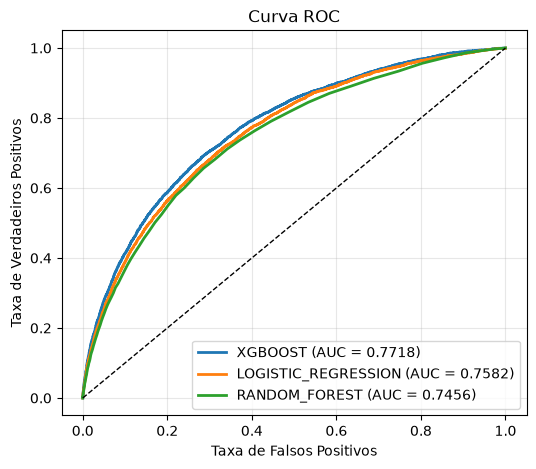

In [4]:
# --- CÉLULA 4: Comparação entre células método AUC/ROC--
plt.figure(figsize=(6, 5))
for model_name in df_resumo["Modelo"]:
    model, threshold = carregar_modelo(store, model_name)
    X_aligned = alinhar_features(model, X_test)

    # Predição
    probs = model.predict_proba(X_aligned)[:, 1]

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.4f})', lw=2)

plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title(f'Curva ROC')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

No gráfico, queremos aproximar o melhor possível ao ponto (0,1), que indicaria um modelo perfeitamente discriminativo. Claramente isto será impossível, pois os comportamentos humanos dos clientes são impossíveis de predir. Os 3 modelos são bastante semelhantes, mas o XGBoost é ligeiramente acima dos outros 2 modelos.

A linha apontilhada representa um AUC de 0.5, significando 50% de classificação correta e 50% de classificação incorreta, ou seja, aleatória. Queremos estar acima desta linha.

Carregando: models/XGBOOST/model.pkl


Carregando: models/LOGISTIC_REGRESSION/model.pkl


Carregando: models/RANDOM_FOREST/model.pkl


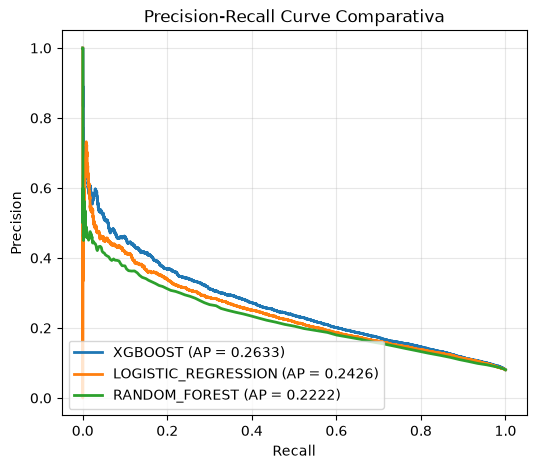

In [5]:
# --- CÉLULA 5: Precision-Recall Curve comparativa ---

plt.figure(figsize=(6, 5))
for model_name in df_resumo ["Modelo"]:
    model, threshold = carregar_modelo(store, model_name)
    X_aligned = alinhar_features (model, X_test)

    # Predição
    probs = model.predict_proba(X_aligned)[:, 1]

    # Precision x Recall
    precision, recall, threshold = precision_recall_curve(y_test, probs)
    ap_score = average_precision_score(y_test, probs)
    plt.plot(recall, precision, label=f'{model_name} (AP = {ap_score:.4f})', lw=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve Comparativa')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.show()


Esse PR Curve mostra como Precision e Recall variam conforme o threshold de classificação é alterado, com cada ponto da curva sendo um threshold diferente.
Representando o trade-off entre estas 2 métricas.

Aumentando o recall, o modelo identifica mais inadimplentes mas por consequência também aumenta a quantidade de falsos positivos, diminuindo a precisão.

Observa-se que o XGBoost mantém a maior precisão para praticamente todos os níveis de recall, resultando no maior valor de AP (Average Precision). Um desempenho consistemente superior.

Carregando: models/XGBOOST/model.pkl


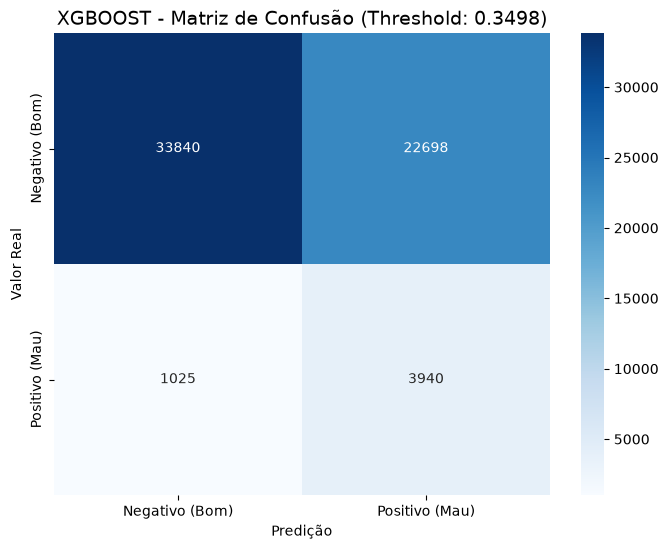

Carregando: models/LOGISTIC_REGRESSION/model.pkl


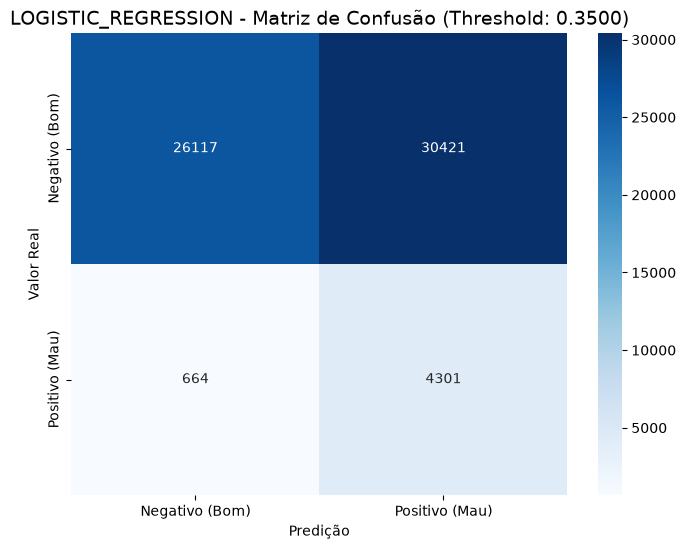

Carregando: models/RANDOM_FOREST/model.pkl


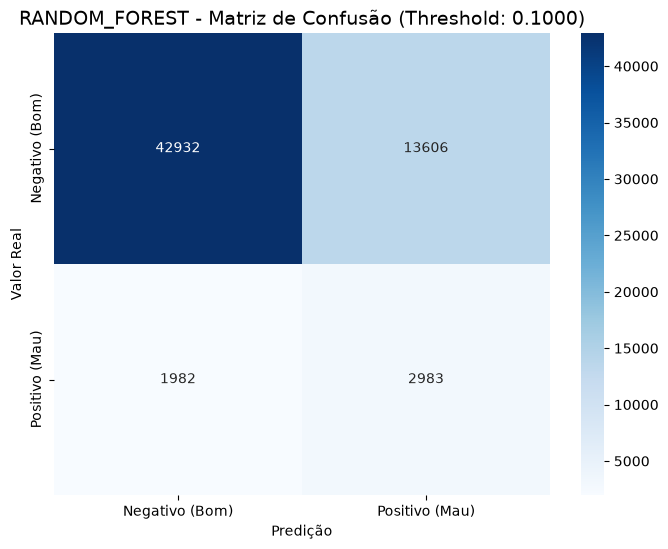

In [6]:
# --- CÉLULA 6: Matriz de Confusão ---

for model_name in df_resumo ["Modelo"]:
    model, threshold = carregar_modelo(store, model_name)
    X_aligned = alinhar_features (model, X_test)

    # Predição
    probs = model.predict_proba(X_aligned)[:, 1]
    y_pred = (probs >= threshold).astype(int)

    # plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_test, y_pred), 
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negativo (Bom)', 'Positivo (Mau)'], 
                yticklabels=['Negativo (Bom)', 'Positivo (Mau)'])

    plt.title(f'{model_name} - Matriz de Confusão (Threshold: {threshold:.4f})', fontsize=14)
    plt.xlabel('Predição')
    plt.ylabel('Valor Real')
    plt.show()

In [7]:
# --- CÉLULA 7: Investigação de Viés por Fontes Externas ---
# Vamos comparar o EXT_SOURCE_2 (que geralmente é muito forte)
# entre os Falsos Positivos e o resto da base.

# Recalcula as predições do CAMPEÃO explicitamente — sem isso, o y_pred
# reaproveitado seria o do ÚLTIMO modelo do loop anterior, não o do melhor.
campeao = df_resumo.iloc[0]["Modelo"]
model, threshold = carregar_modelo(store, campeao)
probs = model.predict_proba(alinhar_features(model, X_test))[:, 1]
y_pred = (probs >= threshold).astype(int)

fp_indices = (y_test == 0) & (y_pred == 1)
df_fp = X_test[fp_indices]
df_outros = X_test[~fp_indices]

print(f"--- Comparação de Fontes Externas ({campeao}) ---")
print(f"Média EXT_SOURCE_2 nos Falsos Positivos: {df_fp['EXT_SOURCE_2'].mean():.4f}")
print(f"Média EXT_SOURCE_2 no restante da base: {df_outros['EXT_SOURCE_2'].mean():.4f}")

# Dica: Se a média dos FP for muito baixa, o modelo está "viciado"
# em reprovar quem tem score baixo nessas fontes, ignorando que o DTI é bom.

Carregando: models/XGBOOST/model.pkl


--- Comparação de Fontes Externas (XGBOOST) ---
Média EXT_SOURCE_2 nos Falsos Positivos: 0.4322
Média EXT_SOURCE_2 no restante da base: 0.5632


Os falsos positivos do modelo campeão (XGBoost) apresentaram média de EXT_SOURCE_2 inferior à do restante da base (0,4322 vs. 0,5632), indicando que o modelo tende a associar valores baixos dessa variável a maior risco de inadimplência. No entanto, essa evidência por si não caracteriza viés e deve ser complementada por análises de interpretabilidade, como SHAP (célula 10).

Carregando: models/XGBOOST/model.pkl


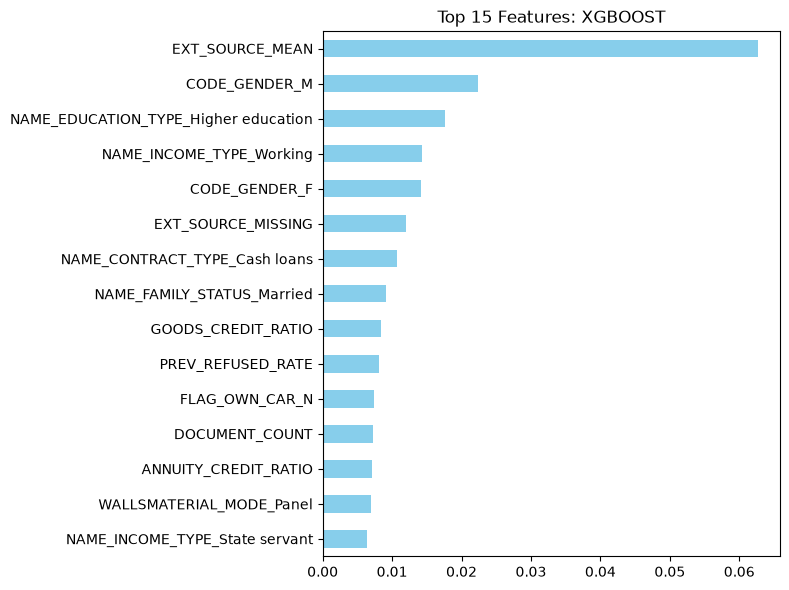

Carregando: models/LOGISTIC_REGRESSION/model.pkl


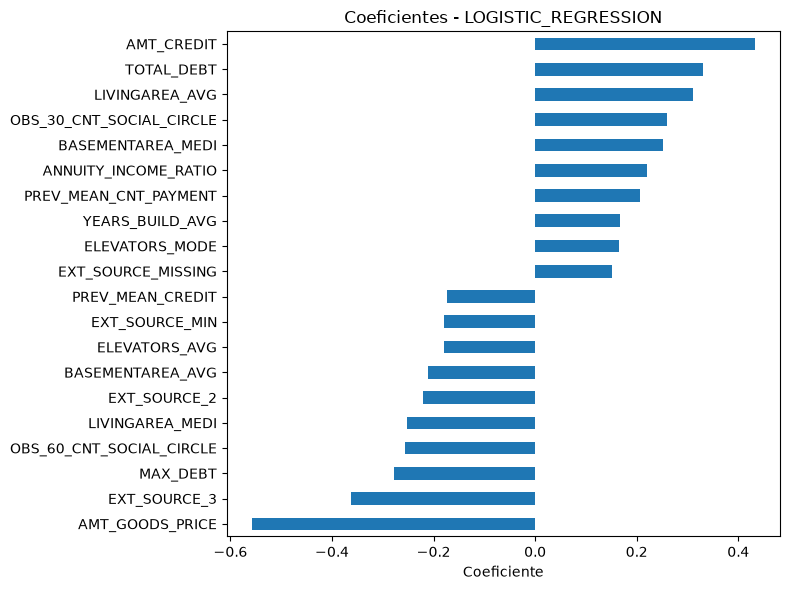

Carregando: models/RANDOM_FOREST/model.pkl


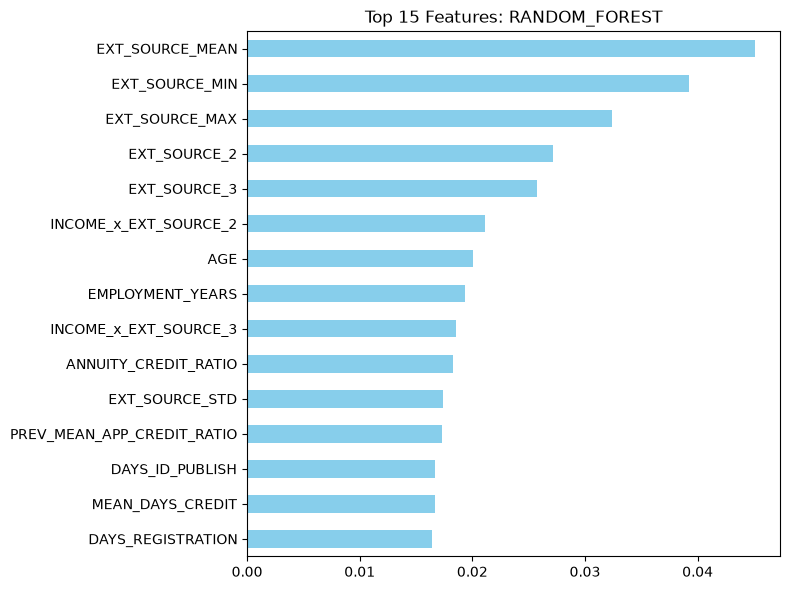

In [8]:
# --- CÉLULA 8: interpretabilidade específica ---

for model_name in df_resumo ["Modelo"]:
    model, threshold = carregar_modelo(store, model_name)
    est = model.named_steps['model'] if isinstance(model, Pipeline) else model
    if model_name in ["XGBOOST","RANDOM_FOREST"]:
        if hasattr(est, 'feature_importances_'):
            imp = pd.Series(est.feature_importances_, index=feature_names).nlargest(15)
            plt.figure(figsize=(8, 6))
            imp.sort_values().plot(kind='barh', color='skyblue')
            plt.title(f'Top 15 Features: {model_name}')
            plt.tight_layout()
            plt.show()
            plt.close()

    else:       
        if hasattr(est, 'coef_'):
            coef = pd.Series(est.coef_[0], index=feature_names)

            top_positivos = coef.nlargest(10)
            top_negativos = coef.nsmallest(10)

            coef_plot = pd.concat([top_negativos, top_positivos])

            plt.figure(figsize=(8, 6))
            coef_plot.sort_values().plot(kind="barh")
            plt.title(f"Coeficientes - {model_name}")
            plt.xlabel("Coeficiente")
            plt.tight_layout()
            plt.show()
            plt.close()


In [9]:
# --- CÉLULA 9: Conclusão ---
display(df_resumo)
best_model = df_resumo.iloc[0]
# Extrair principais métricas
nome_modelo = best_model["Modelo"]
roc_auc = best_model["ROC AUC"]
acuracia = best_model["Acurácia"]
precisao = best_model["Precisão"]
recall = best_model["Recall"]
f1 = best_model["F1"]
threshold = best_model["Threshold"]
# Exibir resumo do modelo campeão
print("=== Modelo Campeão ===")
print(f"Modelo: {nome_modelo}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Acurácia: {acuracia:.4f}")
print(f"Precisão: {precisao:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"Threshold: {threshold:.4f}")
# Texto final interpretativo
print("\n=== Conclusão ===")
print(
    f"O modelo com melhor desempenho geral foi o {nome_modelo}, "
    f"apresentando ROC AUC de {roc_auc:.4f}. "
    "A escolha considera principalmente a capacidade de separação entre bons e maus pagadores, "
    "além do equilíbrio observado entre precisão, recall e F1-score."
)

,Modelo,ROC AUC,Acurácia,Precisão,Recall,F1,Threshold
0,XGBOOST,0.771782,0.614279,0.147909,0.793555,0.249343,0.349770
2,LOGISTIC_REGRESSION,0.758208,0.494578,0.123870,0.866264,0.216746,0.349997
1,RANDOM_FOREST,0.745601,0.746549,0.179818,0.600806,0.276793,0.100000


=== Modelo Campeão ===
Modelo: XGBOOST
ROC AUC: 0.7718
Acurácia: 0.6143
Precisão: 0.1479
Recall: 0.7936
F1-score: 0.2493
Threshold: 0.3498

=== Conclusão ===
O modelo com melhor desempenho geral foi o XGBOOST, apresentando ROC AUC de 0.7718. A escolha considera principalmente a capacidade de separação entre bons e maus pagadores, além do equilíbrio observado entre precisão, recall e F1-score.


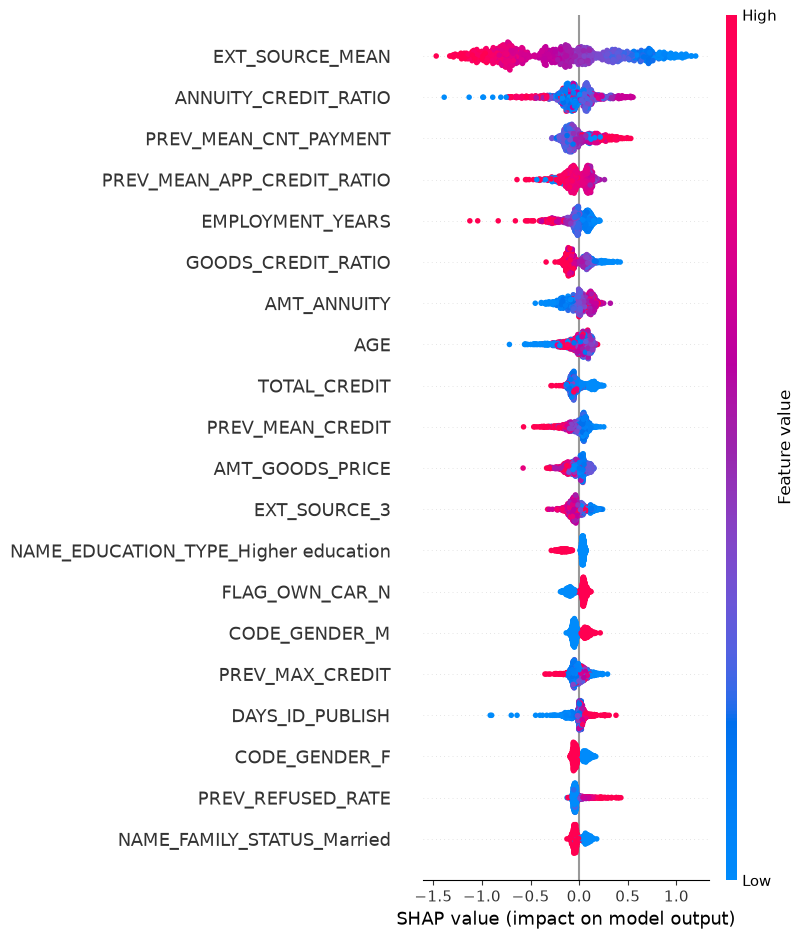

In [10]:
# --- CÉLULA 10: Interpretabilidade com SHAP ---
import shap

# 1. Cria o objeto explicador para o modelo XGBoost
with store.open("models", "models/XGBOOST/model.pkl", "rb") as fh:
    model = joblib.load(fh)
explainer = shap.TreeExplainer(model)

with store.open("models", "evaluation_data/X_train.pkl", "rb") as fh:
    X_train = joblib.load(fh)
with store.open("models", "evaluation_data/y_train.pkl", "rb") as fh:
    y_train = joblib.load(fh)

# 2. Calcula os valores SHAP para uma amostra dos dados (ex: primeiras 1000 linhas)
# Usar uma amostra acelera o processamento em bases grandes como a da Home Credit 
shap_values = explainer.shap_values(X_train.iloc[:1000])

# 3. Gráfico de Resumo (Substitui ou complementa a Feature Importance) 
# Mostra o impacto global e a direção (se a variável aumenta ou diminui o risco)
shap.summary_plot(shap_values, X_train.iloc[:1000])

#### EXT_SOURCE_MEAN

É a feature mais importante para o modelo. Os pontos azuis (valores baixos) estão principalmente à direita, e aumentam o risco de inadimplência. Os pontos vermelhos (valores altos) estão principalmente à esquerda, indicando redução de risco.

#### ANNUITY_CREDIT_RATIO

Outra feature indicando o poder de influencia a decisão do modelo, embora com efeito menor.

Este gráfico SHAP apresenta a importância global das variáveis e a direção de sua influência nas previsões do modelo.

Observa-se que EXT_SOURCE_MEAN é a variável mais relevante, apresentando o maior impacto nas decisões do XGBoost. Valores baixos dessa variável tendem a aumentar a probabilidade prevista de inadimplência, enquanto valores elevados reduzem esse risco. 

Também se destacam variáveis relacionadas às características do financiamento e ao histórico de crédito, como ANNUITY_CREDIT_RATIO, PREV_MEAN_CNT_PAYMENT e PREV_MEAN_APP_CREDIT_RATIO, além de características do cliente, como EMPLOYMENT_YEARS e AGE. 

De modo geral, o modelo concentra suas decisões em variáveis diretamente relacionadas ao risco de crédito, indicando um comportamento coerente com o contexto do problema.